In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import yfinance as yf
from datetime import date
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import plotly.graph_objects as go

In [15]:
start_date = "2024-01-01"
end_date = date.today().strftime("%Y-%m-%d")
dataFrame = yf.download('BTC-USD',start=start_date,end=end_date,interval='1d')
print(f"dữ liệu từ: {start_date} đến {end_date}:")
print(dataFrame.head())

[*********************100%***********************]  1 of 1 completed

dữ liệu từ: 2024-01-01 đến 2026-05-18:
Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2024-01-01  44167.332031  44175.437500  42214.976562  42280.234375   
2024-01-02  44957.968750  45899.707031  44176.949219  44187.140625   
2024-01-03  42848.175781  45503.242188  40813.535156  44961.601562   
2024-01-04  44179.921875  44770.023438  42675.175781  42855.816406   
2024-01-05  44162.691406  44353.285156  42784.718750  44192.980469   

Price            Volume  
Ticker          BTC-USD  
Date                     
2024-01-01  18426978443  
2024-01-02  39335274536  
2024-01-03  46342323118  
2024-01-04  30448091210  
2024-01-05  32336029347  


In [16]:
df = dataFrame.copy()

In [17]:
df.tail(5)

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-05-13,79277.117188,81276.671875,78725.507812,80476.789062,34075428359
2026-05-14,81051.250000,82005.960938,78909.679688,79276.945312,43731663431
2026-05-15,79065.679688,81634.843750,78635.367188,81046.867188,38183347368
2026-05-16,78131.437500,79173.500000,77630.734375,79066.000000,25895799905
2026-05-17,77887.992188,78507.945312,77712.062500,78116.031250,17324146688


In [18]:
df = df.reset_index()
df['Date'] = df['Date'].dt.strftime('%d-%m-%Y')

In [19]:
df.to_csv('bticoin_dataset.csv',index=False,encoding='utf-8-sig')
print("đã xuất file thành công: bitcoin_dataset.csv")

đã xuất file thành công: bitcoin_dataset.csv


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 868 entries, 0 to 867
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Date, )           868 non-null    str    
 1   (Close, BTC-USD)   868 non-null    float64
 2   (High, BTC-USD)    868 non-null    float64
 3   (Low, BTC-USD)     868 non-null    float64
 4   (Open, BTC-USD)    868 non-null    float64
 5   (Volume, BTC-USD)  868 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 49.3 KB


In [21]:
df.shape

(868, 6)

In [22]:
df.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [23]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,868.000000,868.000000,868.000000,868.000000,8.680000e+02
mean,82601.147627,84001.863317,81056.233110,82559.886647,4.449602e+10
std,20908.927054,21083.305311,20753.201213,20953.107758,2.327317e+10
min,39507.367188,40127.351562,38521.894531,39518.714844,9.344044e+09
25%,65978.054688,67295.837891,64585.174805,65966.777344,2.787926e+10
50%,82588.636719,84227.246094,80647.531250,82586.660156,4.020198e+10
75%,99952.886719,102150.630859,97414.078125,100030.986328,5.545627e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


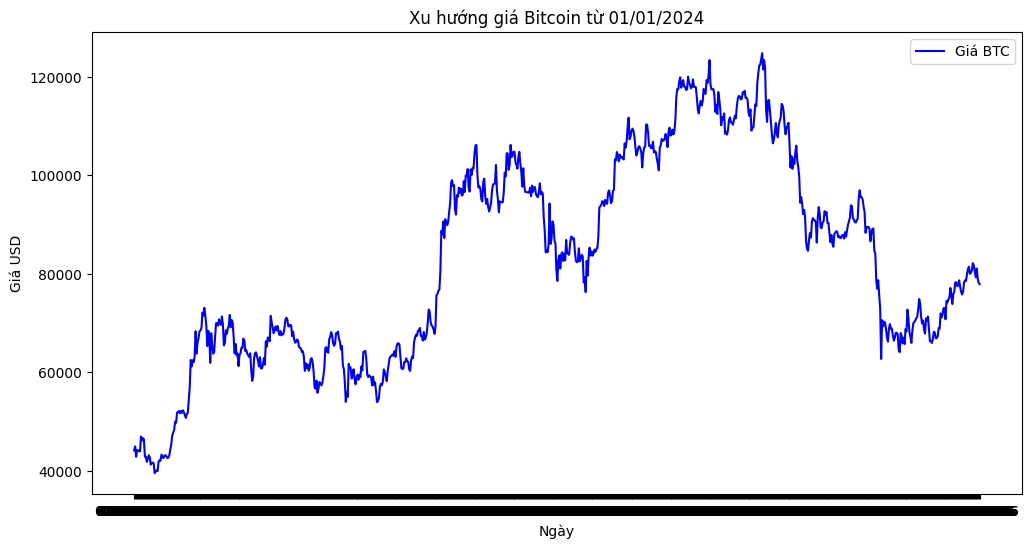

In [24]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], color='blue', label='Giá BTC')
plt.title('Xu hướng giá Bitcoin từ 01/01/2024')
plt.xlabel('Ngày')
plt.ylabel('Giá USD')
plt.legend()
plt.show()

In [25]:
import plotly.express as px
fig = px.line(df, x='Date', y=df['Close'].squeeze(), title='Xu hướng giá Bitcoin từ 01/01/2024')

fig.update_traces(line_color='blue') 
fig.update_layout(xaxis_title='Ngày', yaxis_title='Giá USD')
fig.show()

In [26]:
num_missing = df.isnull().sum()
num_missing[num_missing >0]

Series([], dtype: int64)

In [37]:
ma_1 = 7
ma_2 = 14
ma_3 = 30

df['H-L'] = df['High'] - df['Low']
df['O-C'] = df['Open'] - df['Close']

df[f'SMA_{ma_1}'] = df['Close'].rolling(window=ma_1).mean()
df[f'SMA_{ma_2}'] = df['Close'].rolling(window=ma_2).mean()
df[f'SMA_{ma_3}'] = df['Close'].rolling(window=ma_3).mean()

df[f'SD_{ma_1}'] = df['Close'].rolling(window=ma_1).std()
df[f'SD_{ma_3}'] = df['Close'].rolling(window=ma_3).std()

df.dropna(inplace=True)

In [38]:
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'H-L', 'O-C',
    f'SMA_{ma_1}',
    f'SMA_{ma_2}',
    f'SMA_{ma_3}',
    f'SD_{ma_1}',
    f'SD_{ma_3}'
]
target = 'Close'

In [39]:
time_steps = 30
X = []
y = []
dates = []

for i in range(time_steps, len(df)):
    X.append(df[features].iloc[i-time_steps:i].values.flatten())
    y.append(df[target].iloc[i])
    dates.append(df.index[i])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print(X.shape)
print(y.shape)

(809, 360)
(809, 1)


In [27]:
df_new = df.drop('Date',axis=1)
df_new

C:\Users\NKAQuoc002\AppData\Local\Temp\ipykernel_11596\3761395593.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
1,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
3,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
4,44162.691406,44353.285156,42784.718750,44192.980469,32336029347
...,...,...,...,...,...
863,79277.117188,81276.671875,78725.507812,80476.789062,34075428359
864,81051.250000,82005.960938,78909.679688,79276.945312,43731663431
865,79065.679688,81634.843750,78635.367188,81046.867188,38183347368


In [44]:
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

dates_test = dates[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (647, 360)
X_test: (162, 360)
y_train: (647, 1)
y_test: (162, 1)


In [45]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\NKAQuoc002\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



In [47]:
def relative_error(y_true, y_pred):
    errors = np.abs(y_pred - y_true) / y_true
    return np.mean(errors) * 100

rmse = sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mre = relative_error(y_test, y_pred)

print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))
print("Mean relative errors:", round(mre, 2), "%")

RMSE: 2985.42
MAE: 2287.16
Mean relative errors: 13.95 %


In [ ]:
y_test_1d = np.array(y_test).flatten()
y_pred_1d = np.array(y_pred).flatten()

pd.DataFrame(
    data=np.array([
        y_test_1d,
        y_pred_1d,
        abs(y_test_1d - y_pred_1d),
        abs(y_test_1d - y_pred_1d) / y_test_1d * 100
    ]).T,
    columns=[
        "Thực tế",
        "Dự đoán",
        "Lệch",
        "Lệch (%)"
    ]
).round(2)

,Thực tế,Dự đoán,Lệch,Lệch (%)
0,90405.64,88784.35,1621.29,1.79
1,90640.20,89029.30,1610.90,1.78
2,92691.71,89219.73,3471.98,3.75
3,92020.95,92060.13,39.18,0.04
4,92511.34,92892.51,381.18,0.41
...,...,...,...,...
157,79277.12,81996.65,2719.54,3.43
158,81051.25,81113.56,62.31,0.08
159,79065.68,81811.59,2745.91,3.47
160,78131.44,80840.17,2708.73,3.47


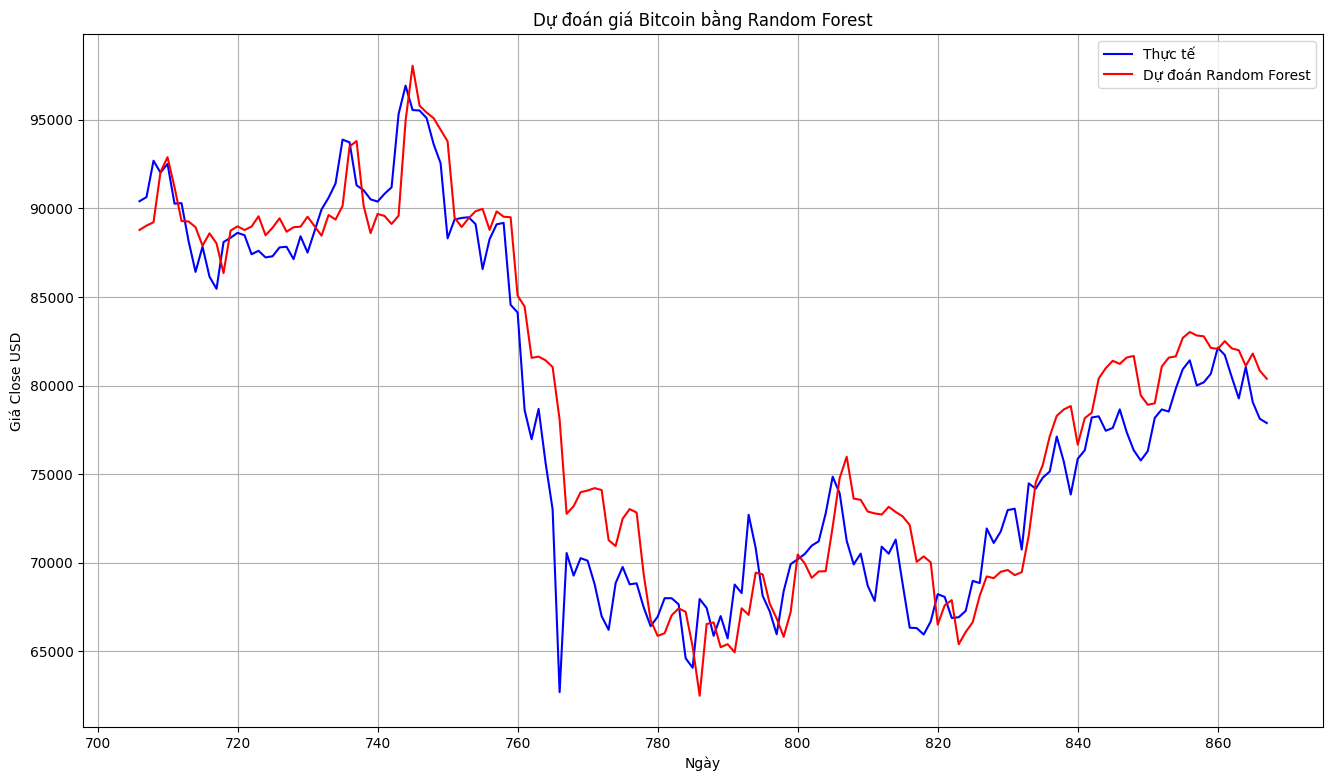

In [58]:
plt.figure(figsize=(16,9))

plt.plot(dates_test, y_test, color='blue', label='Thực tế')
plt.plot(dates_test, y_pred,color='red', label='Dự đoán Random Forest')
plt.title('Dự đoán giá Bitcoin bằng Random Forest')
plt.xlabel('Ngày')
plt.ylabel('Giá Close USD')
plt.legend()
plt.grid(True)
plt.show()